### P2.2 — ML Foundations | Python to Gen AI Course
### P2.2.3 – Supervised Learning: Linear Regression

---
## 🔁 Quick Recap — Where We Are

In **P2.2.2**, we established how any ML problem breaks down:

<img src="ml.png" width="600"/>

**In this chapter, we cover one of the  Supervised Learning algorithms:**
- **Linear Regression** — Regression task (predicting house prices) ← **we start here**

> We won't build these algorithms from scratch — we use ready-made implementations  
> and focus on **when to use them**, **how they work**, and **how to evaluate them**.

---
## 🌍 Real Life — House Price Prediction

Imagine you're a property buyer in Bangalore or Mumbai.

You find a house: **1,600 sq ft, 3 bedrooms, 4 years old.** What's the fair price?

A real estate agent estimates based on experience.  
But platforms like **MagicBricks, 99acres, Zillow** do this automatically — using past sales data.

**Why does this fit Supervised Learning perfectly?**
- Historical data exists: thousands of houses sold, with known prices ✅
- Input features are clear: size, bedrooms, age ✅
- Output is a number (price) → this is a **Regression** problem ✅

The machine learns:
- Bigger house → higher price
- More bedrooms → higher price
- Older house → lower price

It figures out these relationships from data — no rules written by hand.

---

**So — which Regression algorithm do we use?**

We've confirmed: Supervised + Regression task. Now we need to pick the algorithm.

The standard approach is to **look at your data first** — a quick scatter plot of each feature vs the label tells you a lot:

```
House  │ Size (sqft) │ Bedrooms │ Age (yrs) │ Price (₹K)
───────┼─────────────┼──────────┼───────────┼───────────
  1    │    1000     │    2     │    10     │   200
  2    │    1200     │    3     │     5     │   250
  3    │    1500     │    3     │     8     │   300
  4    │    1800     │    4     │     3     │   360
  5    │    2000     │    4     │     2     │   400
  6    │    2300     │    5     │     1     │   450
```

In [5]:
! pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 989.2 kB/s eta 0:00:08
   -- ------------------------------------- 0.5/8.1 MB 989.2 kB/s eta 0:00:08
   -- ------------------------------------- 0.5/8.1 MB 989.2 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.1 MB 559.5 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.1 MB 559.5 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.1 MB 553.0 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.1 MB 553.0 kB/s eta 0:00:13
   ------ --------------------------------- 1.3/8.1 MB 615.7 kB/s eta 0:00:12
   ------- ------------

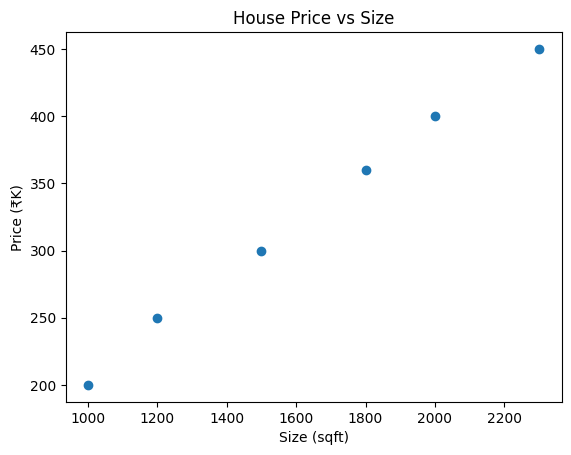

In [6]:
import matplotlib.pyplot as plt

# Data
size = [1000, 1200, 1500, 1800, 2000, 2300]
price = [200, 250, 300, 360, 400, 450]

# Scatter plot
plt.scatter(size, price)

# Labels
plt.xlabel("Size (sqft)")
plt.ylabel("Price (₹K)")
plt.title("House Price vs Size")

# Show plot
plt.show()

**If the scatter shows a roughly straight-line trend → Linear Regression is the right choice.**

| What the plot shows | Algorithm to start with |
|---|---|
| Steady, proportional rise/fall | **Linear Regression** |
| Curved / accelerating pattern | Polynomial Regression |
| Sharp jumps at certain values | Decision Tree Regression |
| Complex pattern, no clear shape | Random Forest / Gradient Boosting |

For our housing data: price rises steadily with size → **Linear Regression fits.**

---

> **What if you can't analyse first?**  
> That's fine — in real projects you don't always have time for deep analysis upfront.  
> The standard ML workflow handles this: **start with the simplest model** (Linear Regression),  
> run it through the full workflow, check the score.  
> If the score is poor, try the next algorithm — same workflow, different algorithm.  
> You compare scores and pick the best. This is normal ML practice, not a shortcut.

---
## 💻 Let's Build It — House Price Predictor

We have 6 houses with known details and prices.

```
House  │ Size (sqft) │ Bedrooms │ Age (yrs) │ Price (₹K)
───────┼─────────────┼──────────┼───────────┼───────────
  1    │    1000     │    2     │    10     │   200
  2    │    1200     │    3     │     5     │   250
  3    │    1500     │    3     │     8     │   300
  4    │    1800     │    4     │     3     │   360
  5    │    2000     │    4     │     2     │   400
  6    │    2300     │    5     │     1     │   450
```

**Features (X):** Size, Bedrooms, Age  &nbsp;&nbsp;|&nbsp;&nbsp;  **Label (y):** Price

**Train-Test Split — why we split the data:**
```
  All 6 houses
  ┌──────────────────────────────────────────────────────┐
  │  TRAIN SET (70%) — model learns from these           │
  │  Houses 1, 2, 3, 4  →  model sees price + features  │
  ├──────────────────────────────────────────────────────┤
  │  TEST SET (30%) — model is evaluated on these        │
  │  Houses 5, 6  →  model predicts price, we compare   │
  └──────────────────────────────────────────────────────┘
       ↑ Model NEVER sees test labels during training.
       This is how we know if it can generalise.
```

In [7]:
import math
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ── DATA ──────────────────────────────────────────────────────────
# Features: [Size (sqft), Bedrooms, Age (years)]
X = [
    [1000, 2, 10],
    [1200, 3,  5],
    [1500, 3,  8],
    [1800, 4,  3],
    [2000, 4,  2],
    [2300, 5,  1],
]
# Labels: Price in thousands (₹)
y = [200, 250, 300, 360, 400, 450]


# ── PHASE 1 : SPLIT ───────────────────────────────────────────────
# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ── PHASE 2 : TRAIN ───────────────────────────────────────────────
# Model learns the pattern from training data only
model = LinearRegression()
model.fit(X_train, y_train)


# ── PHASE 3 : EVALUATE ────────────────────────────────────────────
# Pass both train and test data through the model
train_preds = model.predict(X_train)
test_preds  = model.predict(X_test)

# Compute scores on both
train_r2   = r2_score(y_train, train_preds)
test_r2    = r2_score(y_test,  test_preds)
train_rmse = math.sqrt(mean_squared_error(y_train, train_preds))
test_rmse  = math.sqrt(mean_squared_error(y_test,  test_preds))

print("=== EVALUATION ===")
print(f"Train R2   : {round(train_r2,   2)}   |  Train RMSE : {round(train_rmse, 2)}K")
print(f"Test  R2   : {round(test_r2,    2)}   |  Test  RMSE : {round(test_rmse,  2)}K")

# Compare scores — check for overfit / underfit
print("\n=== FIT CHECK ===")
if train_r2 - test_r2 > 0.15:
    print("⚠️  Overfitting  — model memorized training data, struggles on new data")
elif test_r2 < 0.5:
    print("⚠️  Underfitting — model too simple, missed the pattern")
else:
    print("✅  Good Fit     — train and test scores are close, safe to proceed")


# ── PHASE 4 : INFERENCE ───────────────────────────────────────────
# Only run inference after confirming a good fit above
new_house = [[1600, 3, 4]]   # 1600 sqft, 3 bed, 4 years old
predicted = model.predict(new_house)

print("\n=== INFERENCE ===")
print(f"House  : 1600 sqft, 3 bed, 4 yrs old")
print(f"Predicted Price : ₹{round(predicted[0], 1)}K")

=== EVALUATION ===
Train R2   : 1.0   |  Train RMSE : 0.0K
Test  R2   : 0.92   |  Test  RMSE : 7.13K

=== FIT CHECK ===
✅  Good Fit     — train and test scores are close, safe to proceed

=== INFERENCE ===
House  : 1600 sqft, 3 bed, 4 yrs old
Predicted Price : ₹328.8K


---
## 🔍 Understanding the Results

**R2 Score (0 to 1)**
- Measures how well the model explains the price variation
- `R2 = 1.0` → perfect predictions
- `R2 = 0.0` → model is no better than random guessing
- `R2 = 0.95` → model explains 95% of price variation ✅

**RMSE (Root Mean Squared Error)**
- Lower RMSE = better model

> The model figured out these relationships **automatically from data** — we never told it "bigger = more expensive".

---

### 🎯 Is Your Model Fitting Correctly?

After every model, compare **Train Score** vs **Test Score**:

```
  Train R2 ≈ Test R2 (both high)   →  ✅ Good Fit     — learned the real pattern
  Train R2 >> Test R2               →  ❌ Overfitting  — memorized training data
  Train R2 ≈ Test R2 (both low)    →  ❌ Underfitting — model too simple
```

| Scenario | Train R2 | Test R2 | What it means |
|---|---|---|---|
| ✅ Good Fit | 0.95 | 0.92 | Generalizes well to new houses |
| ❌ Overfitting | 0.99 | 0.60 | Memorized 4 training houses, fails on new ones |
| ❌ Underfitting | 0.55 | 0.52 | Model missed the price pattern entirely |

> With only 6 houses, our model is at risk of overfitting — too few examples.  
> In practice, use **hundreds or thousands** of records. The concept stays identical.

---
## ✅ Pros & Limitations of Linear Regression

**Pros:**
- Simple to understand and explain
- Fast to train — works great for straightforward relationships

**Limitations:**
- Only works well when the relationship is roughly linear (straight-line)
- A tiny dataset (like our 6 houses) gives unreliable results — real models use thousands of records
- Can't capture complex non-linear patterns (e.g. price jumps near a metro station)